Question 1. what is anomaly detection ? Explain its types (point, contextual, and collective anomalies) with examples.

Answer- Anomaly detection is the process of identifying data points, events, or patterns that deviate significantly from the expected or typical behavior in a dataset. It is a crucial technique used across industries to spot fraud, detect system failures, uncover data errors, and highlight unusual occurrences.

Types of Anomalies
Point Anomalies
A point anomaly (global anomaly) is a single data point that differs sharply from all other observations. The deviation can result from errors, rare events, or legitimate but unusual occurrences.

Example: A credit card user typically spends under ₹5,000 per transaction; a sudden purchase of ₹1,00,000 is a point anomaly and may indicate potential fraud.


Contextual Anomalies
A contextual anomaly arises when a data point is anomalous within a particular context, though it may appear normal globally. Contextual anomalies usually occur in time-series or spatial data where contextual factors like time, location, or seasonality matter.

Example: A temperature reading of 30°C might be ordinary in summer but considered highly anomalous in winter.

Example: A 30% drop in website traffic might be expected on a major holiday, but the same drop on a typical working day signifies a contextual anomaly.

Collective Anomalies
Collective anomalies are groups of data points that are only considered anomalous when viewed together, not individually. They typically indicate systemic changes, coordinated events, or persistent problems.

Example: If network traffic gradually increases across multiple sources for a sustained period, this pattern could signal a distributed denial-of-service (DDoS) attack—a collective anomaly.

Question 2. Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of 
their approach and suitable use cases. 

Answer - solation Forest

Effective for high-dimensional datasets.
Works well for large datasets due to efficiency.
Handles mixed variable types (numeric and categorical).
Useful when the majority of data is normal and anomalies are rare.

DBSCAN

Best for datasets with well-separated clusters and irregular shapes.
Suitable for identifying global outliers and noise points in spatial data.
Does not require pre-specifying clusters.
Sensitivity to parameters (eps, min_samples) and struggles with high dimensions.

Local Outlier Factor (LOF)

Ideal for detecting local anomalies in regions of varying density.
Strong for datasets with clusters of different densities.
Provides anomaly scores, not just binary output.
Parameter tuning (neighbors) and careful thresholding needed.
Question 3. What are the key components of a Time Series? Explain each with one 
example.
Answer - The key components of a time series are Trend, Seasonality, Cyclical variation, and Irregular (random) variation. Each component represents a different underlying pattern found in temporal data, and understanding them helps in effective analysis and forecasting.

Trend
The trend component reflects the long-term progression of the series, signifying a persistent upward, downward, or stable movement over time.

Example: The steady rise in the average global temperature over several decades is a trend.

Seasonality
Seasonality refers to patterns that repeat over a fixed period, such as a day, month, or year, typically due to seasonal factors.

Example: Retail sales typically increase every December due to holiday shopping, showing annual seasonality.

Cyclical Variation
Cyclical variation captures patterns that occur at irregular intervals, often spanning multiple years, and are usually influenced by economic or business cycles.

Example: The economy’s boom and recession phases repeat over several years, like recurring business cycles in national GDP.

Irregular (Random) Variation
This component includes unpredictable, irregular, and random fluctuations caused by unforeseen events.

Example: A sudden sales drop due to a natural disaster, such as a flood or earthquake.

These components often combine to form the observed time series, and decomposing them is crucial for understanding temporal data patterns and making accurate predictions.

Question 4. Define Stationary in time series. How can you test and transform a 
non-stationary series into a stationary one? 

Answer - A stationary time series is one whose statistical properties—such as mean, variance, and autocorrelation—remain constant over time. This means the series lacks trend and seasonality, and the probability distribution does not change as time progresses. Stationarity is crucial for many time series models like ARIMA, as these models rely on consistent statistical properties for accurate predictions.

How to Test for Stationarity
Visual Inspection: Plot the series and check for constant mean/variance; trending or seasonality usually indicates non-stationarity.

Summary Statistics: Divide the series into segments and compare mean/variance; large differences imply non-stationarity.

Statistical Tests:

Augmented Dickey-Fuller (ADF) test: Checks for presence of a unit root; a significant result (low p-value) suggests stationarity.

KPSS test: Tests whether the series is stationary around a mean/trend.

Detrending: Remove a fitted trend from the series, such as by linear regression and then subtracting the trend.

Deseasonalizing: Identify and subtract seasonal components using averaging or decomposition techniques like STL or X-12.

Transformation: Apply log, square root, or other functions to stabilize variance if variance changes over time.

By applying these methods, a non-stationary time series can be converted to a stationary one, making it suitable for further modeling and forecasting.


Question 5. Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in 
terms of structure and application.


Answer - AR (Autoregressive)
The AR model predicts future values using a linear combination of past observations.

Example: Predicting today's stock price using prices from previous days.

Use: Serial dependence modeling without error terms or trend/seasonality.

MA (Moving Average)
The MA model forecasts based on linear combinations of past error terms (residuals).

Example: Smoothing temperature variations using past errors.

Use: Captures noise and short-term irregular fluctuations.

ARIMA (Autoregressive Integrated Moving Average)
Combines AR and MA; uses differencing for non-stationarity, suitable for non-seasonal series.

Example: Forecasting monthly sales data without seasonal spikes.

Use: Trends and cycles, not seasonality.

SARIMA (Seasonal ARIMA)
Adds seasonal elements to ARIMA, with extra parameters (P, D, Q, s) for handling seasonality.

Example: Retail sales with spikes every December (holiday season).

Use: Both non-seasonal and seasonal patterns.

SARIMAX (Seasonal ARIMA with eXogenous Variables)
Extends SARIMA by including exogenous (external) variables, allowing the model to factor in other influences (like holidays, marketing campaigns).

Example: Sales forecasting influenced by advertising spend, holidays, and seasonal effects.

Use: Seasonality plus known external factors.

These models are chosen based on data characteristics, such as the presence of trend, seasonality, and external influences. SARIMAX offers the most flexibility for complex, real-world scenarios involving both seasonal patterns and outside drivers.


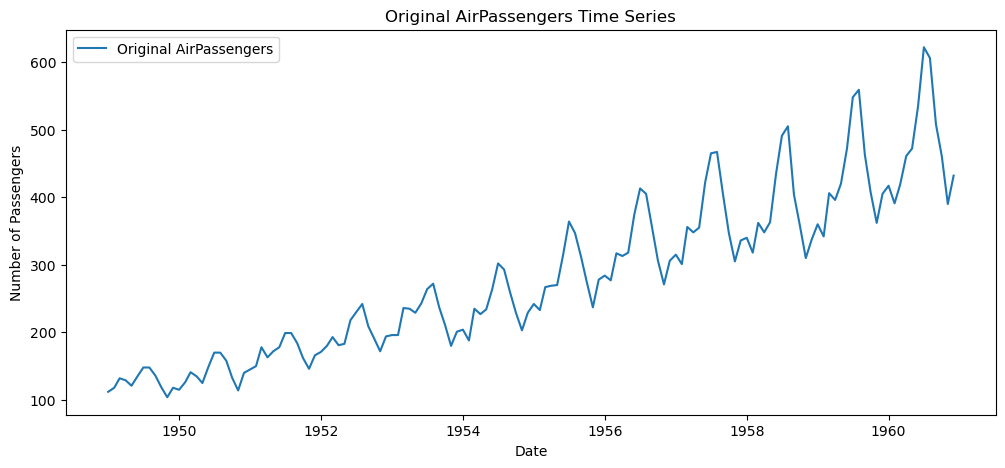

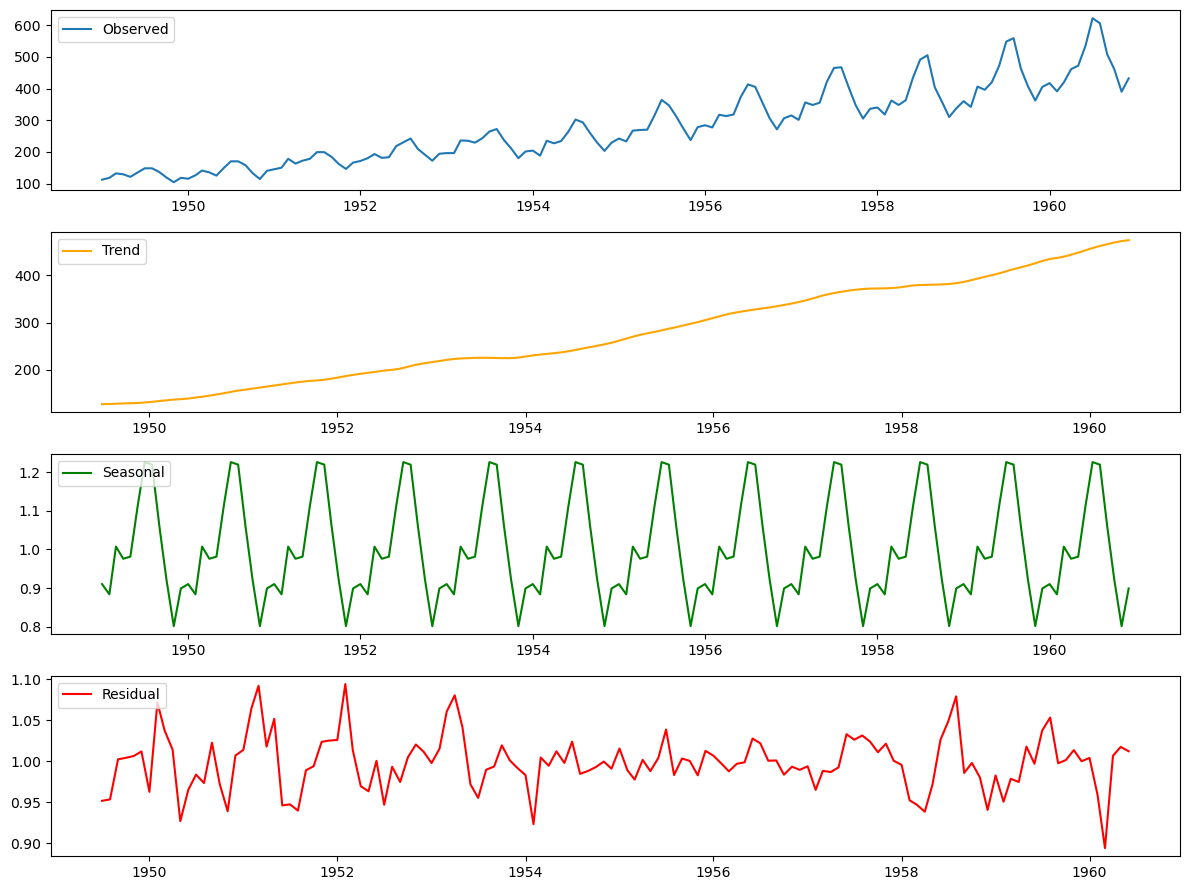

In [1]:
#Question 6. Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components 
#Answer
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Load AirPassengers dataset from CSV
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Decompose the time series using multiplicative model
result = seasonal_decompose(data['Passengers'], model='multiplicative')

# Plot original series
plt.figure(figsize=(12, 5))
plt.plot(data, label='Original AirPassengers')
plt.title('Original AirPassengers Time Series')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

# Plot decomposed components
plt.figure(figsize=(12, 9))
plt.subplot(411)
plt.plot(result.observed, label='Observed')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(result.trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(result.seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(result.resid, label='Residual', color='red')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


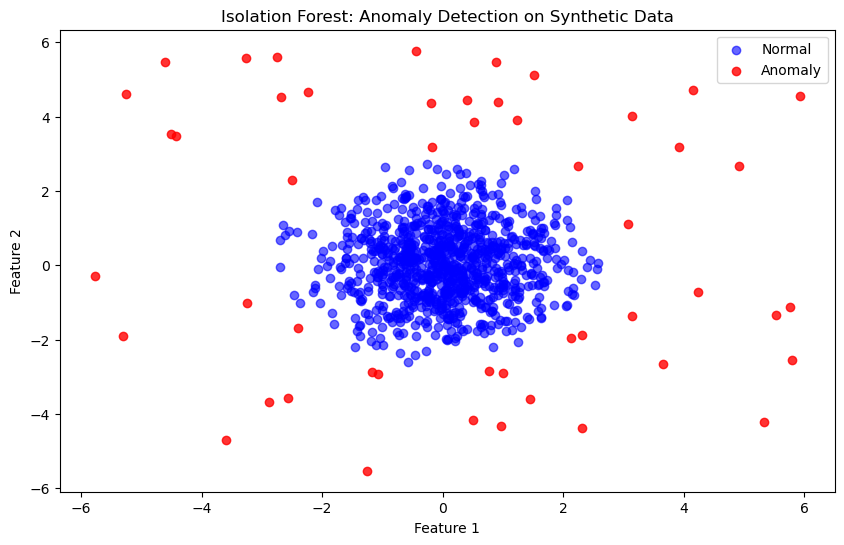

In [2]:
#Question 7.Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot. 
#Ansswer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Generate synthetic data with normal points and anomalies
np.random.seed(42)
X_normal = np.random.randn(950, 2)  # Normal data points
X_outliers = np.random.uniform(low=-6, high=6, size=(50, 2))  # Anomalies

# Combine the data
X = np.vstack((X_normal, X_outliers))

# Initialize and fit the Isolation Forest model
clf = IsolationForest(contamination=0.05, random_state=42)
clf.fit(X)

# Predict anomalies (-1 for anomalies, 1 for normal)
labels = clf.predict(X)

# Plot the data points with anomalies highlighted
plt.figure(figsize=(10, 6))
plt.scatter(X[labels == 1, 0], X[labels == 1, 1], c='blue', label='Normal', alpha=0.6)
plt.scatter(X[labels == -1, 0], X[labels == -1, 1], c='red', label='Anomaly', alpha=0.8)
plt.title('Isolation Forest: Anomaly Detection on Synthetic Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


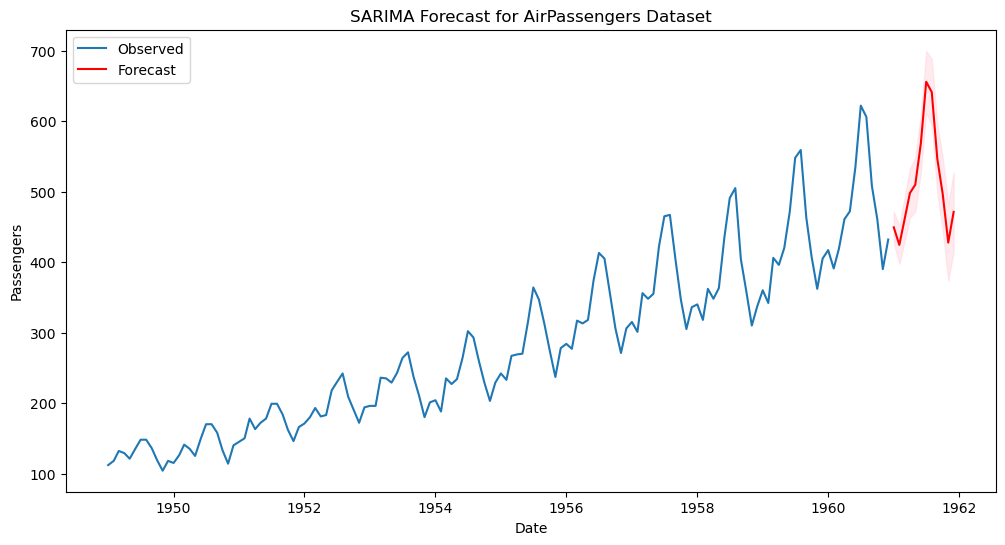

In [4]:
#Question 8.Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results. 
#Answer
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load the AirPassengers dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
data = data['Passengers']

# Train SARIMA model
# order = (p,d,q), seasonal_order = (P,D,Q,s) with s=12 for monthly seasonality
model = SARIMAX(data, order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit(disp=False)

# Forecast next 12 months
forecast = model_fit.get_forecast(steps=12)
forecast_index = pd.date_range(start=data.index[-1] + pd.offsets.MonthBegin(), periods=12, freq='MS')

# Extract forecast mean and confidence intervals
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Plot observed and forecasted values
plt.figure(figsize=(12, 6))
plt.plot(data, label='Observed')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA Forecast for AirPassengers Dataset')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()


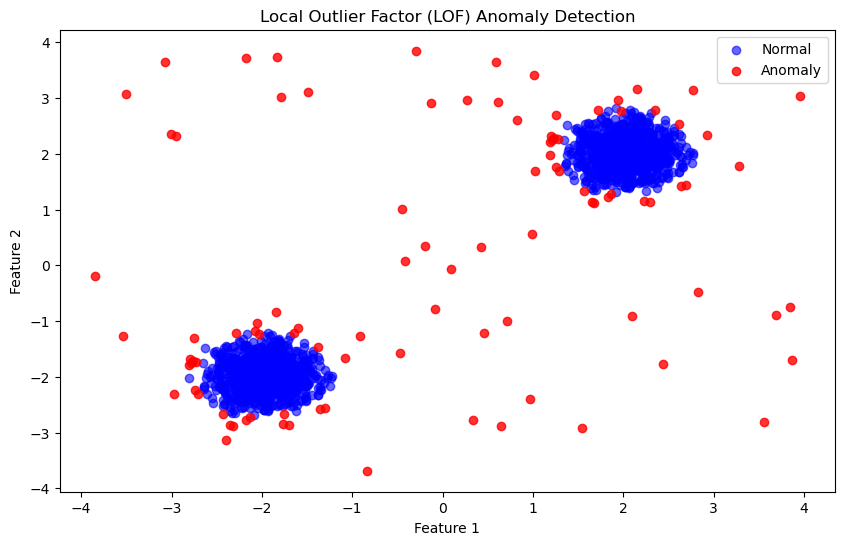

In [5]:
#Question 9. Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib. 
#Answer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Create synthetic data (normal points and anomalies)
np.random.seed(42)
X = 0.3 * np.random.randn(950, 2)
X_outliers = np.random.uniform(low=-4, high=4, size=(50, 2))

# Combine normal data and outliers
X = np.r_[X + 2, X - 2, X_outliers]

# Fit LOF model
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels = clf.fit_predict(X)

# Plot normal vs anomaly points
plt.figure(figsize=(10, 6))
plt.scatter(X[labels == 1, 0], X[labels == 1, 1], c='blue', label='Normal', alpha=0.6)
plt.scatter(X[labels == -1, 0], X[labels == -1, 1], c='red', label='Anomaly', alpha=0.8)
plt.title('Local Outlier Factor (LOF) Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()



Question 10: You are working as a data scientist for a power grid monitoring company. 
Your goal is to forecast energy demand and also detect abnormal spikes or drops in 
real-time consumption data collected every 15 minutes. The dataset includes features 
like timestamp, region, weather conditions, and energy usage. 
Explain your real-time data science workflow: 
● How would you detect anomalies in this streaming data (Isolation Forest / LOF / 
DBSCAN)? 
● Which time series model would you use for short-term forecasting (ARIMA / 
SARIMA / SARIMAX)? 
● How would you validate and monitor the performance over time? 
● How would this solution help business decisions or operations?

Answer -- In the context of forecasting energy demand and real-time anomaly detection for a power grid monitoring company with a streaming dataset collected every 15 minutes that includes timestamp, region, weather, and energy usage, the workflow would be:

Anomaly Detection in Streaming Data
Choice of Algorithm: Isolation Forest or Local Outlier Factor (LOF) are suitable due to their efficiency and adaptability.

Isolation Forest is well-suited for high-dimensional data and large-scale streaming applications, as it isolates anomalies efficiently without relying heavily on data distribution assumptions.

LOF effectively captures local density deviations, which helps detect contextual anomalies like sudden spikes localized to specific regions or weather conditions.

Implementation:

Use a sliding window approach to process the most recent data batch for anomaly detection.

Combine features like energy usage, weather stats, and region indicators.

Update the anomaly detection model frequently or use incremental approaches to adapt to changes in data distribution.

DBSCAN may not be ideal for streaming data due to its batch clustering nature and sensitivity to parameter tuning.

Time Series Model for Short-term Forecasting
SARIMAX is preferable for this use case:

Handles short-term and seasonal patterns in 15-minute interval data (seasonality due to daily cycles or weekly patterns).

Incorporates exogenous variables like weather conditions and region-specific effects, improving forecast accuracy.

Handles non-stationary data with differencing.

ARIMA and SARIMA models handle non-seasonal and seasonal parts respectively but do not incorporate exogenous variables directly, making SARIMAX more appropriate given auxiliary weather and region features.

Validation and Monitoring
Validation:

Split data into training and test sets while maintaining time order.

Use rolling or expanding window cross-validation for realistic forecasting performance check.

Evaluate using metrics like Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

Evaluate anomaly detection using precision, recall, and F1-score, leveraging labeled anomaly data if available.

Monitoring:

Continuously monitor forecast errors and anomaly detection alerts.

Track model drift via statistical tests or change detection in residuals and error distributions.

Set thresholds for retraining models when performance degrades.

Use dashboards for real-time tracking and alerting.

Business Impact and Operational Benefits
Operational Efficiency: Early detection of abnormal energy spikes or drops enables rapid troubleshooting and mitigation, reducing outage risks or grid instability.

Demand Planning: Accurate short-term forecasting helps in scheduling generation assets optimally and managing load balancing.

Cost Savings: Prevents over or under-production, decreasing energy wastage and minimizing costs.

Customer Satisfaction: Consistent energy supply with fewer interruptions improves end-user experience.

Strategic Decisions: Data-driven insights on consumption patterns and weather impact enable proactive grid upgrades or policy formulations.